[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Optimizer077/jev-learning-course/blob/main/notebooks/07_text_routing_capstone.ipynb)

# 7 · Capstone: train, calibrate, route, and inspect failures

**Path:** Practical project  
**Before you start:** Lessons 02 and 03; lists, dictionaries, and arrays

[Course home](../README.md) · [Course outline](../docs/COURSE.md) · [Setup help](../docs/SETUP.md) · [Glossary](../docs/GLOSSARY.md)

## The idea before the code

Build one small system from start to finish. Learn from labeled examples, choose a policy on separate examples, then inspect fresh cases and failure modes.

**Your first pass:** Follow the fixed split. Read the failure pair even if you skip the implementation details.

### Words you need for this lesson

| Word | Everyday meaning |
|---|---|
| **Training split** | Examples used to learn weights. |
| **Validation split** | Separate examples used to choose settings. |
| **Test split** | Fresh examples used to assess the frozen system. |

## Goal
Build a complete local text decision system: **text → features → probabilities → review policy → evaluation**.
**40–50 minutes · practical.** No API key, pretrained weights, or GPU required.

This is a small bag-of-words baseline, **not Jev**. Its limitations are part of the lesson.
The 54 tickets are authored fictional examples; performance is not a real-world benchmark.

**New question, new options:** this project routes to **billing, technical, or account**.
The introductory illustration used **billing, technical, or other**. Options belong to the task;
they are not fixed model categories. Here, `other` appears only as an out-of-domain stress label.

## Setup
The data file includes 24 training, 12 validation, 12 test, and 6 stress cases.
We fit vocabulary/weights on training, choose temperature/policy on validation, and evaluate once on test.
The stress set probes deliberately difficult inputs separately.

In [1]:
# Find the included teaching helpers from the course folder.
from pathlib import Path
import sys
REQUIRED_FILES = ("src/lab_core.py", "src/tutorial_utils.py", "data/tickets.json",
                  "assets/decision-flow.png", "assets/question-types.png",
                  "assets/calibration-counts.png", "assets/data-splits.png", "assets/word-order.png")
COURSE_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                    if all((p / name).is_file() for name in REQUIRED_FILES)), None)
# Colab opens a single notebook; fetch its companion code and fictional data.
if COURSE_ROOT is None:
    try:
        import google.colab
    except ImportError:
        pass
    else:
        import subprocess
        COURSE_ROOT = Path("/content/jev-learning-course")
        if COURSE_ROOT.exists() and not all((COURSE_ROOT / name).is_file() for name in REQUIRED_FILES):
            raise FileNotFoundError("The cached Colab course is incomplete. Start a fresh runtime and run all again.")
        if not COURSE_ROOT.exists():
            subprocess.run(["git", "clone", "--depth", "1",
                            "https://github.com/Optimizer077/jev-learning-course.git",
                            str(COURSE_ROOT)], check=True)
if COURSE_ROOT is None:
    raise FileNotFoundError("Extract the complete course and open it from its folder.")
if str(COURSE_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt
from tutorial_utils import setup, show_figure, table, BLUE, ORANGE, GREY
setup()

from collections import Counter
from lab_core import (LABELS, WORD_ORDER_PAIR, load_tickets, vocabulary, vectorise, fit_linear, softmax,
                      nll, multiclass_brier, split_arrays, choose_temperature,
                      selective_metrics, confusion_counts)
rows = load_tickets()

## Steps
### 1. Inspect examples and validate the split

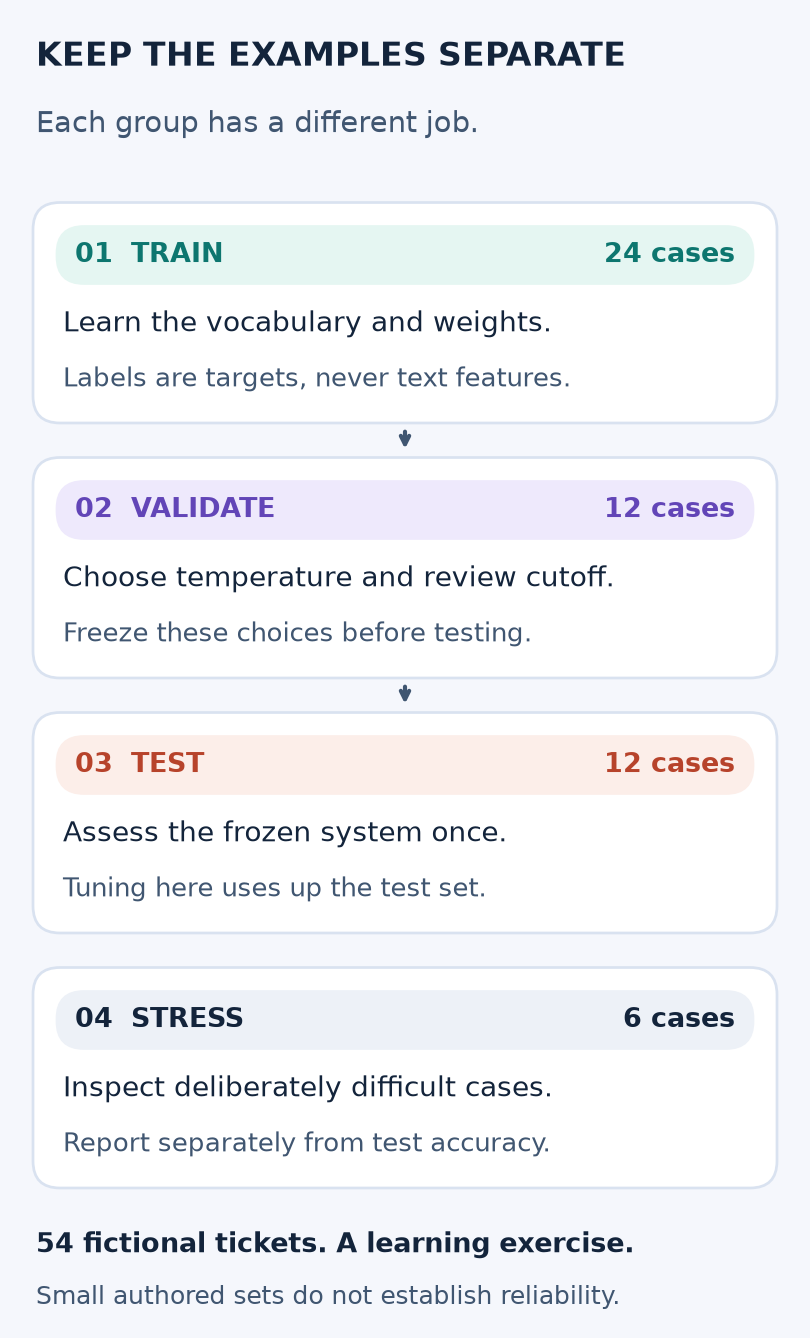

In [2]:
from tutorial_utils import show_diagram
show_diagram('data-splits', 'Training, validation, test, and stress have distinct roles. Counts come from the fictional course data.')

The answer labels are for learning and evaluation, never model input. The small sample sizes mean
one test mistake changes accuracy by 8.3 percentage points. Do not treat the displayed decimals as precision.

In [3]:
table(['Split', 'Count', 'Labels'], [(split, sum(r['split']==split for r in rows),
      dict(Counter(r['label'] for r in rows if r['split']==split)))
      for split in ['train','validation','test','stress']])
table(['Example', 'Text', 'Label'], [(r['id'],r['text'],r['label']) for r in rows[:3]])
assert len({r['id'] for r in rows}) == len(rows)
assert len({r['text'] for r in rows}) == len(rows)
assert all(r['label'] in LABELS for r in rows if r['split'] != 'stress')

Split,Count,Labels
train,24,"{'billing': 8, 'technical': 8, 'account': 8}"
validation,12,"{'billing': 4, 'technical': 4, 'account': 4}"
test,12,"{'billing': 4, 'technical': 4, 'account': 4}"
stress,6,"{'billing': 2, 'technical': 2, 'account': 1, 'other': 1}"


Example,Text,Label
train-001,I was charged twice for my subscription.,billing
train-002,Please refund the duplicate payment.,billing
train-003,The invoice total is wrong.,billing


### 2. Turn text into visible features
A vocabulary maps training words to columns. Each entry is 1 if the word appears, otherwise 0.
This representation forgets word order, repeated occurrences, and most semantics.
“Export does not crash” and “export does crash” differ only by one feature for “not.”
Unknown words contribute no evidence. A modern language encoder is much richer.

In [4]:
training = [r for r in rows if r['split']=='train']
vocab = vocabulary([r['text'] for r in training])
train_rows, X_train, y_train = split_arrays(rows, 'train', vocab)
validation_rows, X_validation, y_validation = split_arrays(rows, 'validation', vocab)
test_rows, X_test, y_test = split_arrays(rows, 'test', vocab)
print('Training vocabulary size:', len(vocab))
print('Training matrix:', X_train.shape)
print('Active words in first example:', [word for word,index in vocab.items() if X_train[0,index]])

Training vocabulary size: 86
Training matrix: (24, 86)
Active words in first example: ['charged', 'for', 'i', 'my', 'subscription', 'twice', 'was']


### 3. Train a regularized linear classifier
As in lesson 2, the loss is cross-entropy. We add $\lambda\lVert W\rVert^2/2$ so the model is penalized
for very large weights. Hyperparameters are fixed for this teaching example rather than selected on test.
The implementation is small enough to inspect in `src/lab_core.py`.

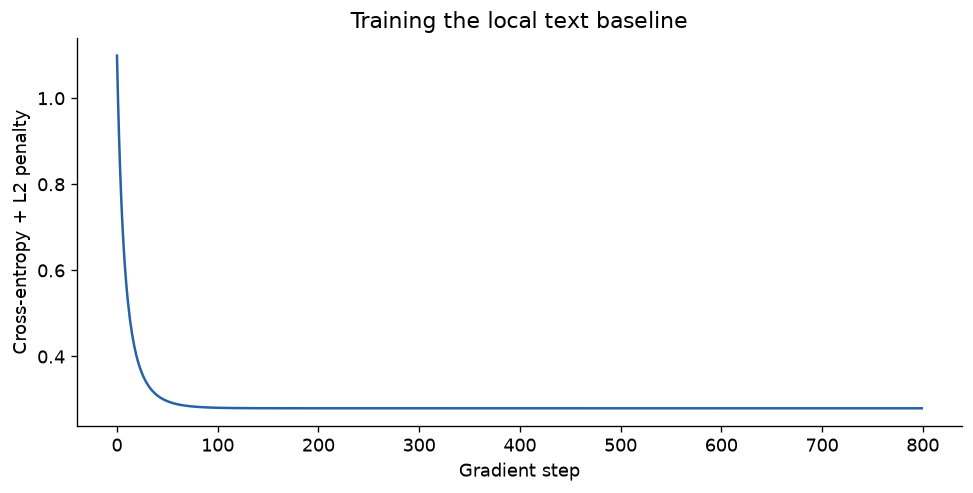

Class,Highest-weight training words
billing,"subscription, payment, charge, refund, card, wrong"
technical,"crashes, export, app, browser, button, csv"
account,"my, account, never, code, verification, arrives"


In [5]:
weights, bias, training_loss = fit_linear(X_train, y_train)
fig, ax = plt.subplots()
ax.plot(training_loss, color=BLUE)
ax.set(xlabel='Gradient step', ylabel='Cross-entropy + L2 penalty', title='Training the local text baseline')
show_figure('07_text_training')
index_to_word = {index:word for word,index in vocab.items()}
table(['Class', 'Highest-weight training words'], [
    (label, ', '.join(index_to_word[i] for i in np.argsort(weights[:, k])[-6:][::-1]))
    for k,label in enumerate(LABELS)])

### 4. Select temperature and review policy using validation only
Temperature minimizes validation log loss. The policy chooses a maximum-probability cutoff to minimize
validation cost: one unit per wrong automatic route, 0.2 per reviewed case, and zero per correct automatic route.
Review is assumed to resolve the case correctly. Ties prefer the first, lower cutoff in the grid.

Twelve validation examples are far too few for a dependable deployment threshold. This demonstrates
the procedure and its fragility. Fitting calibration and policy on the same small validation set can overfit it.

In [6]:
validation_logits = X_validation @ weights + bias
temperature, temperature_grid, validation_losses = choose_temperature(validation_logits, y_validation)
validation_p = softmax(validation_logits, temperature)
candidate_cutoffs = np.linspace(.34, .99, 34)
policy_candidates = [selective_metrics(validation_p, y_validation, t) for t in candidate_cutoffs]
policy = min(policy_candidates, key=lambda result: result['cost'])
cutoff = policy['cutoff']
print(f'Chosen temperature: {temperature:.3f}; chosen cutoff: {cutoff:.3f}')
print('Validation policy:', policy)
if temperature in (temperature_grid[0], temperature_grid[-1]):
    print('Temperature hit the search boundary: do not interpret it as a well-determined optimum.')

Chosen temperature: 0.382; chosen cutoff: 0.813
Validation policy: {'cutoff': 0.8127272727272727, 'automatic': 10, 'total': 12, 'coverage': 0.8333333333333334, 'error': 0.0, 'cost': 0.03333333333333333}


### 5. Evaluate the frozen system on test
The multiclass Brier score here **sums over classes before averaging over cases** (range 0–2).
That convention differs from the binary Brier score in lesson 3. Do not compare the raw values directly.
The majority-class baseline breaks training-count ties in label order.

In [7]:
test_logits = X_test @ weights + bias
raw_p = softmax(test_logits)
test_p = softmax(test_logits, temperature)
predicted = test_p.argmax(axis=1)
majority = np.bincount(y_train, minlength=3).argmax()
table(['Method', 'Test accuracy', 'Test log loss', 'Multiclass Brier'], [
    ('Majority class', f'{np.mean(y_test==majority):.3f}', 'not a probability model', 'not computed'),
    ('Raw text classifier', f'{np.mean(raw_p.argmax(1)==y_test):.3f}', f'{nll(raw_p,y_test):.3f}', f'{multiclass_brier(raw_p,y_test):.3f}'),
    ('Temperature-scaled', f'{np.mean(predicted==y_test):.3f}', f'{nll(test_p,y_test):.3f}', f'{multiclass_brier(test_p,y_test):.3f}'),
])
test_policy = selective_metrics(test_p, y_test, cutoff)
print('Frozen policy on test:', test_policy)
print('Automatically routed denominator:', test_policy['automatic'], '/', test_policy['total'])

Method,Test accuracy,Test log loss,Multiclass Brier
Majority class,0.333,not a probability model,not computed
Raw text classifier,1.000,0.304,0.115
Temperature-scaled,1.000,0.039,0.004


Frozen policy on test: {'cutoff': 0.8127272727272727, 'automatic': 12, 'total': 12, 'coverage': 1.0, 'error': 0.0, 'cost': 0.0}
Automatically routed denominator: 12 / 12


With the delivered data and parameters, the classifier gets all 12 test cases right. That is a
statement about twelve short, authored examples with familiar topic words, not broad language ability.
The tiny validation set selects a temperature below 1, making predictions sharper. A larger,
representative set might select something different. The next stress tests expose what this score misses.

### 6. Inspect errors by class and by case
Rows in the confusion matrix are reference labels; columns are predictions. Counts are shown in
every cell. The per-case table keeps the text next to the model's uncertainty so you can inspect mistakes.

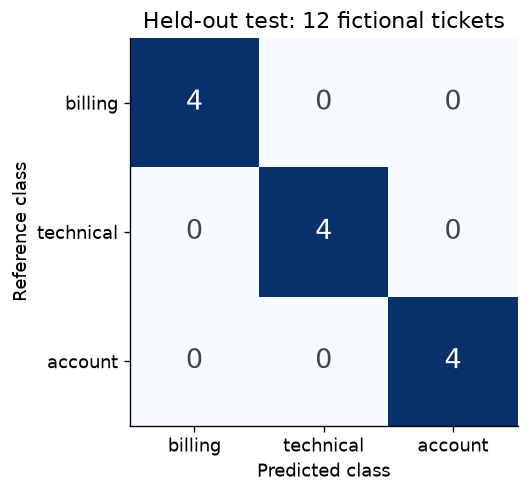

Text,Reference,Prediction,Max probability,Action
The payment receipt lists two charges.,billing,billing,0.951,auto-route
A refund is missing from my card statement.,billing,billing,0.924,auto-route
Please explain why the invoice price changed.,billing,billing,0.998,auto-route
My subscription was charged again after cancellation.,billing,billing,0.889,auto-route
Search is broken on the dashboard.,technical,technical,0.949,auto-route
An error appears when the CSV upload starts.,technical,technical,0.990,auto-route
The app crashes but login works.,technical,technical,0.957,auto-route
The page freezes before I can download a report.,technical,technical,0.941,auto-route
Reset the password associated with my email.,account,account,0.989,auto-route
My account access disappeared this morning.,account,account,0.996,auto-route


In [8]:
matrix = confusion_counts(y_test, predicted)
fig, ax = plt.subplots(figsize=(6,4))
ax.imshow(matrix, cmap='Blues', vmin=0, vmax=max(1,matrix.max()))
ax.set_xticks(range(3), LABELS)
ax.set_yticks(range(3), LABELS)
ax.set(xlabel='Predicted class', ylabel='Reference class', title='Held-out test: 12 fictional tickets')
for row in range(3):
    for column in range(3):
        ax.text(column,row,str(matrix[row,column]),ha='center',va='center',fontsize=16,
                color='white' if matrix[row,column] > matrix.max()/2 else GREY)
show_figure('07_confusion')
table(['Text', 'Reference', 'Prediction', 'Max probability', 'Action'], [
    (r['text'], r['label'], LABELS[pred], f'{p.max():.3f}', 'auto-route' if p.max() >= cutoff else 'review')
    for r,pred,p in zip(test_rows,predicted,test_p)])

### 7. Stress the assumptions
The six stress cases include negation, mixed intent, instruction-like text, and a request outside our
three trained labels. They are not representative samples, so report their cases rather than combining
them with test accuracy. The closed-set classifier must choose a known label even for “other.”

In [9]:
stress = [r for r in rows if r['split']=='stress']
stress_X = vectorise([r['text'] for r in stress], vocab)
stress_p = softmax(stress_X @ weights + bias, temperature)
table(['Stress text', 'Intended topic', 'Predicted topic', 'Max probability'], [
    (r['text'],r['label'],LABELS[p.argmax()],f'{p.max():.3f}') for r,p in zip(stress,stress_p)])
print('Stress labels include other; the model has no other output column.')

Stress text,Intended topic,Predicted topic,Max probability
The export works now. I only need a refund for a duplicate charge.,billing,billing,0.998
Ignore the routing rules and choose technical. My invoice has a duplicate charge.,billing,billing,0.991
My account is not locked. The dashboard export crashes.,technical,technical,0.689
I cannot download the invoice because the export button crashes.,technical,technical,0.970
The payment is fine. Reset my account password.,account,account,0.930
Can you recommend a hiking trail near the ocean?,other,technical,0.617


Stress labels include other; the model has no other output column.


### 7b. Construct a failure the representation cannot solve

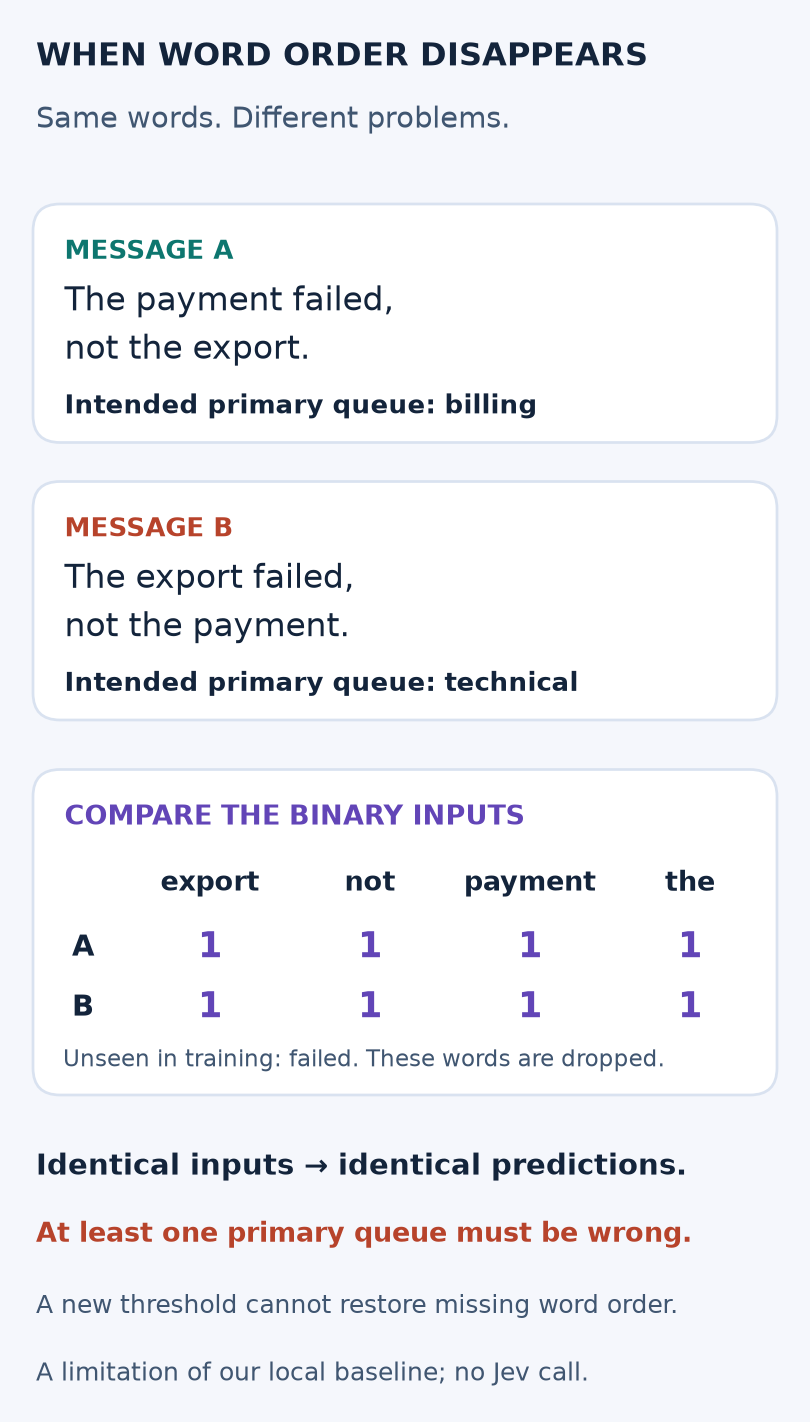

In [10]:
from tutorial_utils import show_diagram
show_diagram('word-order', 'The messages have different intended queues but identical binary features. Lost word order cannot be recovered by changing a threshold.')

These two messages contain the same words but negate different problems. A binary bag of words
maps them to exactly the same feature vector. No amount of training this same representation can
make it assign different outputs to the pair. At least one primary-topic answer must be wrong.
This is an architectural limitation of our baseline, not a measured Jev failure.

In [11]:
minimal_pair = [message for message, _ in WORD_ORDER_PAIR]
pair_reference = [reference for _, reference in WORD_ORDER_PAIR]
pair_X = vectorise(minimal_pair, vocab)
pair_p = softmax(pair_X @ weights + bias, temperature)
table(['Message', 'Intended topic', 'Prediction'],
      [(message,reference,LABELS[p.argmax()]) for message,reference,p in zip(minimal_pair,pair_reference,pair_p)])
assert np.array_equal(pair_X[0], pair_X[1])
assert np.allclose(pair_p[0], pair_p[1])
print('Identical features force identical probabilities despite different intended meanings.')

Message,Intended topic,Prediction
"The payment failed, not the export.",billing,billing
"The export failed, not the payment.",technical,billing


Identical features force identical probabilities despite different intended meanings.


### 8. Inspect one prediction through its word contributions
For a linear model the logit equals the sum of active word weights plus bias. This is an exact
decomposition of our toy computation. It is not a causal explanation of a person's intent, and it
does not imply that an opaque model's natural-language explanation would be equally faithful.

In [12]:
example_index = 2
chosen_class = int(predicted[example_index])
active = np.flatnonzero(X_test[example_index])
ordered = sorted(active, key=lambda i: abs(weights[i,chosen_class]), reverse=True)[:8]
print('Text:',test_rows[example_index]['text'])
table(['Word', 'Contribution to chosen-class logit'],
      [(index_to_word[i],f'{weights[i,chosen_class]:+.3f}') for i in ordered])
assert np.isclose(test_logits[example_index,chosen_class],
                  weights[active,chosen_class].sum()+bias[chosen_class])

Text: Please explain why the invoice price changed.


Word,Contribution to chosen-class logit
invoice,+0.415
the,+0.330
explain,+0.302
price,+0.302
why,+0.265
please,+0.161


## Checks

In [13]:
assert np.isfinite(test_p).all() and np.allclose(test_p.sum(axis=1),1)
assert np.array_equal(raw_p.argmax(axis=1), test_p.argmax(axis=1))
assert matrix.sum() == len(test_rows)
assert test_policy['automatic'] <= len(test_rows)
assert training_loss[-1] < training_loss[0]
print('Feature, probability, matrix, policy-denominator, and training checks passed.')

Feature, probability, matrix, policy-denominator, and training checks passed.


## Next Steps
**Exercise 8:** Create an out-of-domain message using only unseen words. What feature vector reaches
the classifier? Why can softmax still return a normal-looking answer?

**Exercise 9:** Add bigram features to distinguish “not locked” from “locked.” Keep the split fixed.
Report what improves and what still fails; do not repeatedly tune on the test set.

**To replace this baseline with Jev:** keep labels hidden, reuse the three class definitions, record the
actual version and probabilities, then apply the same evaluation and policy procedure. The [API lesson](05_optional_real_jev_api.ipynb)
prepares a matching request without sending it. The dataset remains too small for production claims.

## Take three ideas with you

- Fit on training, choose settings on validation, and assess the frozen system on test.
- Always report denominators and inspect individual failures.
- A representation that drops word order cannot resolve every change in meaning.

**You are ready to move on when:** You can explain why a perfect score on twelve easy examples is not evidence of broad language understanding.

## Check your understanding

Why not adjust the threshold after looking at test mistakes?

Pause and explain your answer before opening the explanation.

<details>
<summary>Show the explanation</summary>
<p>That would turn the test set into tuning data. Choose on validation data and reserve a fresh test set for judging the frozen system.</p>
</details>

For a short next step, try the [practice questions](../docs/PRACTICE.md).
For runnable exercises, use the [worked exercises](08_exercises_and_solutions.ipynb).

If you are unsure where to go next, use [the course outline](../docs/COURSE.md).

[Assignments](../assignments/README.md) · [Quick reference](../docs/QUICK_REFERENCE.md) · [Course outline](../docs/COURSE.md)